# Hyperedge curvature within vs between clusters, split by cardinality

## 1. Configuration

In [ ]:
from pathlib import Path

# --- inputs -----------------------------------------------------------------
ROOT = Path('MY_PATH/clustering_ML')

CURVATURE_PATH = ROOT / 'results/synthetic_data/cluster_id1_low/hyperedge/OR_MMOT_curvature.txt'
CLUSTERS_PATH  = ROOT / 'data/synthetic_data/true_clusters/cluster_id1_low.txt'

# --- classification ---------------------------------------------------------
ASSIGNMENT_MODE = 'strict'         # 'strict' | 'majority' | 'linear'

# What 'between clusters' means:
#   'unassigned' -> ASSIGNMENT_MODE failed to give the edge a single cluster
#   'impure'     -> the edge touches more than one cluster (mode independent)
BETWEEN_DEFINITION = 'unassigned'

# --- per-cardinality behaviour ----------------------------------------------
MIN_EDGES_PER_PLOT = 1    # skip a cardinality holding fewer hyperedges than this
MIN_PER_GROUP = 3         # below this many edges in either group, report the test as NaN

# --- plot -------------------------------------------------------------------
HIST_BINS = 25            # only used when the curvature is not integer valued
DENSITY = False           # True normalises each group, useful when the two differ a lot in size
SHARED_BINS = False       # True = identical bin edges across every cardinality
SAVE_DIR = None           # e.g. ROOT / 'figures'; None = do not write files

In [11]:
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import mannwhitneyu

plt.rcParams.update({
    'figure.dpi': 110,
    'axes.grid': True,
    'grid.alpha': 0.25,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

# Colour-blind-safe pair; the hatching keeps the split alive in greyscale.
C_WITHIN, C_BETWEEN = '#0072B2', '#D55E00'

## 2. Loading

In [12]:
def _coerce(token):
    """Cluster labels become ints where possible, otherwise stay strings."""
    try:
        return int(token)
    except ValueError:
        return token


def load_curvature_file(path):
    """Parse `n1,n2,n3 : curvature` lines; the ROW NUMBER is the hyperedge id.

    An explicit leading id column (`edge_id <tab> n1,n2,... : curvature`) is also
    accepted. Returns {edge_id: (nodes,)} and {edge_id: float}.
    """
    edges, curvature, skipped = {}, {}, 0

    for row, raw in enumerate(Path(path).read_text().splitlines(), start=1):
        line = raw.strip()
        if not line:
            skipped += 1
            continue

        left, sep, right = line.rpartition(':')
        if not sep:                        # no ':' on the line
            left, right = line, ''

        fields = left.split()
        if not fields:
            skipped += 1
            continue

        # The node list is the field holding commas; anything before it is an
        # explicit edge id, otherwise the row number is the edge id.
        node_idx = next((i for i, f in enumerate(fields) if ',' in f), len(fields) - 1)
        eid = row
        if node_idx > 0:
            try:
                eid = int(fields[0])
            except ValueError:
                eid = row

        try:
            nodes = tuple(sorted({int(x) for x in fields[node_idx].split(',') if x.strip()}))
        except ValueError:
            skipped += 1
            continue
        if not nodes:
            skipped += 1
            continue

        edges[eid] = nodes
        try:
            curvature[eid] = float(right.strip())
        except ValueError:
            curvature[eid] = float('nan')

    if skipped:
        print('  note: skipped', skipped, 'blank/unparseable line(s) in', Path(path).name)
    return edges, curvature


def load_clusters(path):
    """One cluster label per line, the ROW NUMBER being the node id.

    A two-column `node_id <tab> cluster_id` file is also accepted.
    """
    mapping = {}
    for row, raw in enumerate(Path(path).read_text().splitlines(), start=1):
        fields = raw.split()
        if not fields:
            continue
        if len(fields) >= 2:
            mapping[int(fields[0])] = _coerce(fields[1])
        else:
            mapping[row] = _coerce(fields[0])
    return mapping


edges, curvature = load_curvature_file(CURVATURE_PATH)
node_cluster = load_clusters(CLUSTERS_PATH)

if not edges:
    raise ValueError('No hyperedges parsed from ' + str(CURVATURE_PATH))

print('hyperedges       :', len(edges))
print('curvature values :', sum(not np.isnan(v) for v in curvature.values()), '/', len(edges))
print('cardinalities    :', sorted(Counter(len(v) for v in edges.values()).items()))
print('nodes w/ cluster :', len(node_cluster),
      '-> clusters', sorted(set(node_cluster.values()), key=str))

missing = {n for ns in edges.values() for n in ns} - set(node_cluster)
if missing:
    print('warning:', len(missing), 'node(s) in edges have no cluster label,',
          'e.g.', sorted(missing)[:10])

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\ckeat\\github-projects\\Summer_Research\\python_19_05_files\\clustering_ML\\results\\synthetic_data\\cluster_id1_low\\hyperedge\\OR_MMOT_curvature.txt'

## 3. Within or between clusters

In [ ]:
def classify(nodes, node_cluster, mode=ASSIGNMENT_MODE, between=BETWEEN_DEFINITION):
    """Return (assigned cluster or None, is_between) for one hyperedge."""
    labels = [node_cluster[n] for n in nodes if n in node_cluster]
    if not labels:
        return None, True

    counts = Counter(labels)
    n = len(labels)
    top, top_count = counts.most_common(1)[0]

    if mode == 'strict':
        assigned = top if len(counts) == 1 else None
    elif mode == 'majority':
        assigned = top if 2 * top_count > n else None
    elif mode == 'linear':
        tied = sum(1 for k in counts.values() if k == top_count)
        assigned = top if tied == 1 else None
    else:
        raise ValueError('unknown mode ' + repr(mode) + '; expected strict / majority / linear')

    if between == 'unassigned':
        is_between = assigned is None
    elif between == 'impure':
        is_between = len(counts) > 1
    else:
        raise ValueError("BETWEEN_DEFINITION must be 'unassigned' or 'impure'")

    return assigned, is_between


rows = []
for eid, nodes in edges.items():
    cluster, is_between = classify(nodes, node_cluster)
    rows.append({
        'edge_id': eid,
        'nodes': nodes,
        'cardinality': len(nodes),          # k = |e|
        'curvature': curvature.get(eid, float('nan')),
        'cluster': cluster,
        'is_between': is_between,
    })

df = pd.DataFrame(rows).sort_values('edge_id').reset_index(drop=True)
df['membership'] = np.where(df['is_between'], 'between clusters', 'within cluster')
df = df.dropna(subset=['curvature'])

print('mode =', repr(ASSIGNMENT_MODE), '  between =', repr(BETWEEN_DEFINITION))
print(df.pivot_table(index='cardinality', columns='membership', values='curvature',
                     aggfunc=['size', 'mean']).round(3))

mode = 'strict'   between = 'unassigned'
                        size                            mean               
membership  between clusters within cluster between clusters within cluster
cardinality                                                                
2                        192           1195           -1.107         -0.835
3                        113            438           -0.828         -0.656
4                         58            217           -0.765         -0.614


## 4. One histogram and one test per cardinality

The test is one-sided with the arrays passed as `(within, between)` and
`alternative='greater'`, i.e.

* **H0**: within-cluster curvature is not stochastically larger than between-cluster;
* **H1**: within-cluster curvature *is* stochastically larger (between sits lower).

`rank-biserial r` is the effect size: 0 means the two groups interleave completely, 1 means
every within-cluster edge outranks every between-cluster edge.

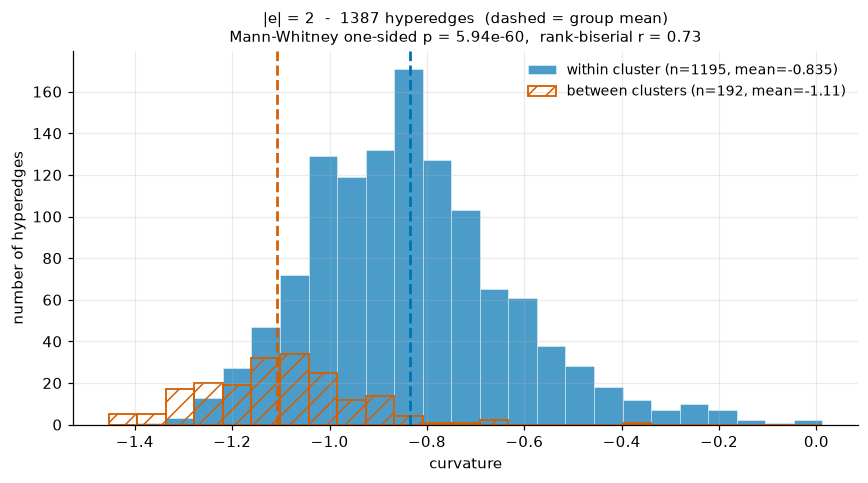

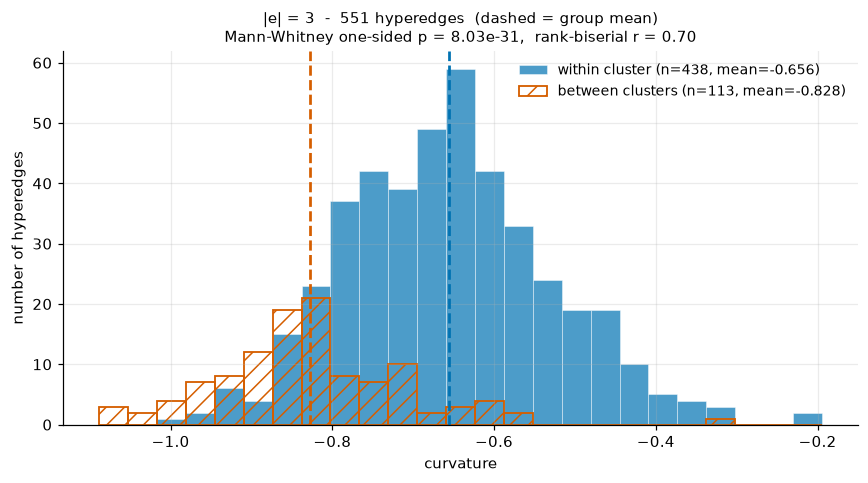

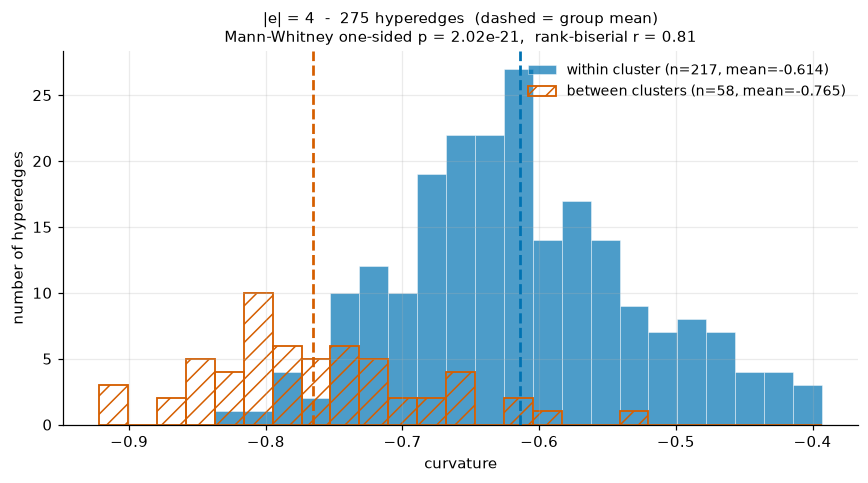

In [ ]:
def _bin_edges(values, bins=HIST_BINS):
    """Integer-aligned bins when the curvature is integer valued, else regular bins."""
    v = np.asarray(values, dtype=float)
    v = v[~np.isnan(v)]
    if v.size == 0:
        return np.linspace(0.0, 1.0, 2)
    if np.allclose(v, np.round(v)) and (v.max() - v.min()) <= 60:
        return np.arange(v.min() - 0.5, v.max() + 1.5, 1.0)
    return np.histogram_bin_edges(v, bins=bins)


GLOBAL_BINS = _bin_edges(df['curvature'].to_numpy())

results = []

for k in sorted(df['cardinality'].unique()):
    sub = df[df['cardinality'] == k]
    if len(sub) < MIN_EDGES_PER_PLOT:
        continue

    vw = sub.loc[~sub['is_between'], 'curvature'].to_numpy()
    vb = sub.loc[sub['is_between'], 'curvature'].to_numpy()

    # ---- test ---------------------------------------------------------------
    if len(vw) >= MIN_PER_GROUP and len(vb) >= MIN_PER_GROUP:
        res = mannwhitneyu(vw, vb, alternative='greater')
        U, p = float(res.statistic), float(res.pvalue)
        rbc = 2 * U / (len(vw) * len(vb)) - 1
    else:
        U = p = rbc = float('nan')

    results.append({
        'cardinality': k,
        'n_within': len(vw),
        'n_between': len(vb),
        'mean_within': vw.mean() if len(vw) else np.nan,
        'mean_between': vb.mean() if len(vb) else np.nan,
        'median_within': np.median(vw) if len(vw) else np.nan,
        'median_between': np.median(vb) if len(vb) else np.nan,
        'U': U,
        'p_value': p,
        'rank_biserial_r': rbc,
    })

    # ---- plot ---------------------------------------------------------------
    bin_edges = GLOBAL_BINS if SHARED_BINS else _bin_edges(sub['curvature'].to_numpy())

    fig, ax = plt.subplots(figsize=(8, 4.5))

    if len(vw):
        ax.hist(vw, bins=bin_edges, density=DENSITY, color=C_WITHIN, alpha=0.70,
                edgecolor='white', linewidth=0.4,
                label='within cluster (n=' + str(len(vw)) +
                      ', mean=' + format(vw.mean(), '.3g') + ')')
        ax.axvline(vw.mean(), color=C_WITHIN, linestyle='--', linewidth=1.8)

    if len(vb):
        ax.hist(vb, bins=bin_edges, density=DENSITY, facecolor='none', edgecolor=C_BETWEEN,
                hatch='//', linewidth=1.2,
                label='between clusters (n=' + str(len(vb)) +
                      ', mean=' + format(vb.mean(), '.3g') + ')')
        ax.axvline(vb.mean(), color=C_BETWEEN, linestyle='--', linewidth=1.8)

    subtitle = ('Mann-Whitney one-sided p = ' + format(p, '.3g') +
                ',  rank-biserial r = ' + format(rbc, '.2f')) if np.isfinite(p) else \
               ('test skipped: fewer than ' + str(MIN_PER_GROUP) + ' edges in a group')

    ax.set_xlabel('curvature')
    ax.set_ylabel('density' if DENSITY else 'number of hyperedges')
    ax.set_title('|e| = ' + str(k) + '  -  ' + str(len(sub)) +
                 ' hyperedges  (dashed = group mean)\n' + subtitle, fontsize=10)
    ax.legend(fontsize=9, frameon=False)
    fig.tight_layout()

    if SAVE_DIR is not None:
        out = Path(SAVE_DIR)
        out.mkdir(parents=True, exist_ok=True)
        fig.savefig(out / ('curvature_k' + str(k) + '_' + ASSIGNMENT_MODE + '.png'),
                    bbox_inches='tight', dpi=150)

    plt.show()

per_cardinality = pd.DataFrame(results).set_index('cardinality')

## 5. All tests side by side

In [ ]:
def holm(pvals):
    """Holm-Bonferroni adjusted p-values; NaNs pass through and are not counted."""
    p = np.asarray(pvals, dtype=float)
    out = np.full(p.shape, np.nan)
    idx = np.flatnonzero(np.isfinite(p))
    if idx.size == 0:
        return out
    order = idx[np.argsort(p[idx])]
    m = idx.size
    running = 0.0
    for rank, i in enumerate(order):
        running = max(running, (m - rank) * p[i])
        out[i] = min(running, 1.0)
    return out


table = per_cardinality.copy()
table['mean_gap'] = table['mean_within'] - table['mean_between']
table['p_holm'] = holm(table['p_value'].to_numpy())
table['significant_0.05'] = table['p_holm'] < 0.05

print('One-sided Mann-Whitney U, per cardinality')
print('H1: within-cluster curvature > between-cluster curvature')
print('mode =', repr(ASSIGNMENT_MODE), '  between =', repr(BETWEEN_DEFINITION),
      '  tests =', int(table['p_value'].notna().sum()))
print()

cols = ['n_within', 'n_between', 'median_within', 'median_between', 'mean_gap',
        'U', 'p_value', 'p_holm', 'rank_biserial_r', 'significant_0.05']

# p-values keep scientific notation; rounding them to 4 dp turns tiny ones into 0.0.
shown = table[cols].round(4)
for c in ('p_value', 'p_holm'):
    shown[c] = table[c].map(lambda v: format(v, '.3g') if np.isfinite(v) else '-')
shown

One-sided Mann-Whitney U, per cardinality
H1: within-cluster curvature > between-cluster curvature
mode = 'strict'   between = 'unassigned'   tests = 3



,n_within,n_between,median_within,median_between,mean_gap,U,p_value,p_holm,rank_biserial_r,significant_0.05
cardinality,,,,,,,,,,
2,1195,192,-0.8528,-1.1068,0.2726,198632.5,5.94e-60,1.78e-59,0.7315,True
3,438,113,-0.6589,-0.8337,0.1718,42074.0,8.03e-31,1.61e-30,0.7002,True
4,217,58,-0.6212,-0.7772,0.1518,11368.0,2.02e-21,2.02e-21,0.8065,True
